<a href="https://colab.research.google.com/github/ram-creator-1156/Ram_LP_Synapse26/blob/week2_ML/Copy_of_SynapseTask_LP_2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Synapse Week Two**

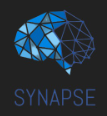



# Synapse Task 2B: SVM & Ensembles

Welcome to Task 2B! In Task 2A, we explored our "individual" baseline classifiers: Logistic Regression, Naive Bayes, and single Decision Trees. You saw firsthand how simple models behave, where their assumptions hold, and how unconstrained trees can run wild with variance.

Now, we level up. In this notebook, we cover **Support Vector Machines (SVM)**—an algorithm that reasons geometrically about margins and hyperplanes—and **Ensemble Methods**, a powerful family of techniques that combine many weak learners into one robust, high-performing model. This notebook closes our classification arc before a dedicated Research Task connecting ensemble techniques back to the Linear Regression you built in Task 1A.

Chalo, let's get building!

## Part 0 — Quick Recap & Rebuild

Before diving into new algorithms, we need our sanitized data ready. We'll reuse the exact same IBM Telco Customer Churn dataset, cleaning steps, and 70:30 train-test split from Task 2A so every comparison remains apples-to-apples.

No new teaching here—just reloading and setting the stage.

In [22]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
# Import base libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [24]:
# Hint: Reload and clean exactly as in Task 2A — TotalCharges coercion, drop NaNs, drop customerID, encode Churn to 0/1, One-Hot encode nominal features, and perform a 70:30 stratified train-test split
# df = pd.read_csv('/content/drive/MyDrive/.../WA_Fn-UseC_-Telco-Customer-Churn.csv')
# df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# df.dropna(subset=['TotalCharges'], inplace=True)
# df.drop(columns=['customerID'], inplace=True)
# df['Churn'] = (df['Churn'] == 'Yes').astype(int)
# df_encoded = pd.get_dummies(df, drop_first=True)
# X = df_encoded.drop(columns=['Churn'])
# y = df_encoded['Churn']
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Exact Task 2A preprocessing: same dataset, cleaning, encoding, and 70:30 stratified split.
df = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Dataset shape after cleaning:", df.shape)
print("Encoded shape:", df_encoded.shape)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Dataset shape after cleaning: (7032, 20)
Encoded shape: (7032, 31)
Train shape: (4922, 30)
Test shape: (2110, 30)


## Part 1 — Support Vector Machines & Kernels

While Logistic Regression searches for any decision boundary separating the classes, Support Vector Machines (SVM) search for the **maximum-margin hyperplane**—the line or plane that stays as far away from the closest training samples as mathematically possible. Those critical points hugging the margin edges are called **support vectors**.

The geometric margin width between the two boundary planes is given by:

$$\text{Margin} = \frac{2}{\|w\|}$$

Maximizing this margin is equivalent to minimizing $\frac{1}{2}\|w\|^2$. When classes cannot be separated with a straight cut in the current feature space, SVM deploys the **Kernel Trick**: it maps data points into a higher-dimensional space where a linear boundary *can* slice them apart cleanly, computing inner products without ever explicitly calculating the expensive coordinate transformations.

### Helpful Resources
- [StatQuest: Support Vector Machines Main Idea](https://www.youtube.com/watch?v=efR1C6CvhmE) *(Visual intuition of margins and soft margins)*
- [SVM Formulation & Boundary Intuition](https://www.youtube.com/watch?v=H9yACitf-KM) *(Short video on hyperplanes)*
- [Demystifying Support Vector Machines](https://towardsdatascience.com/demystifying-support-vector-machines-8453b39f7368/) *(Margin geometry and objective setups)*
- [StatQuest: Polynomial Kernel](https://youtu.be/Toet3EiSFcM) *(Watch how higher dimensions untangle points)*
- [StatQuest: The Radial Basis Function (RBF) Kernel](https://youtu.be/Qc5IyLW_hns) *(Visualizing infinite-dimensional projection)*
- [Kernel Feature Map Derivation](https://xavierbourretsicotte.github.io/Kernel_feature_map.html) *(Optional: rigorous inner-product substitution for curious math folks)*
- [Maths Behind SVM](https://www.youtube.com/watch?v=Js3GLb1xPhc) *(Supplementary video walk-through of the optimization setup)*

### Step 1.1: The Kernel Trick in Action (2D Concentric Circles)

To build visual intuition before tackling our high-dimensional churn data, let's create a synthetic 2D dataset using `make_circles`. A linear boundary cannot separate inner and outer rings—let's see what an RBF kernel does.

In [25]:
# Hint: Generate concentric circles using sklearn.datasets.make_circles
# from sklearn.datasets import make_circles
# X_circ, y_circ =

from sklearn.datasets import make_circles
X_circ, y_circ = make_circles(
    n_samples=500,
    factor=0.45,
    noise=0.08,
    random_state=42
)
print("Shape:", X_circ.shape)


Shape: (500, 2)


In [26]:
# Hint: Fit SVC(kernel='linear') and SVC(kernel='rbf') on (X_circ, y_circ)

from sklearn.svm import SVC
svc_linear = SVC(kernel='linear', C=1.0, random_state=42)
svc_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svc_linear.fit(X_circ, y_circ)
svc_rbf.fit(X_circ, y_circ)
print("Linear-kernel training accuracy:", round(svc_linear.score(X_circ, y_circ), 4))
print("RBF-kernel training accuracy:", round(svc_rbf.score(X_circ, y_circ), 4))


Linear-kernel training accuracy: 0.574
RBF-kernel training accuracy: 1.0


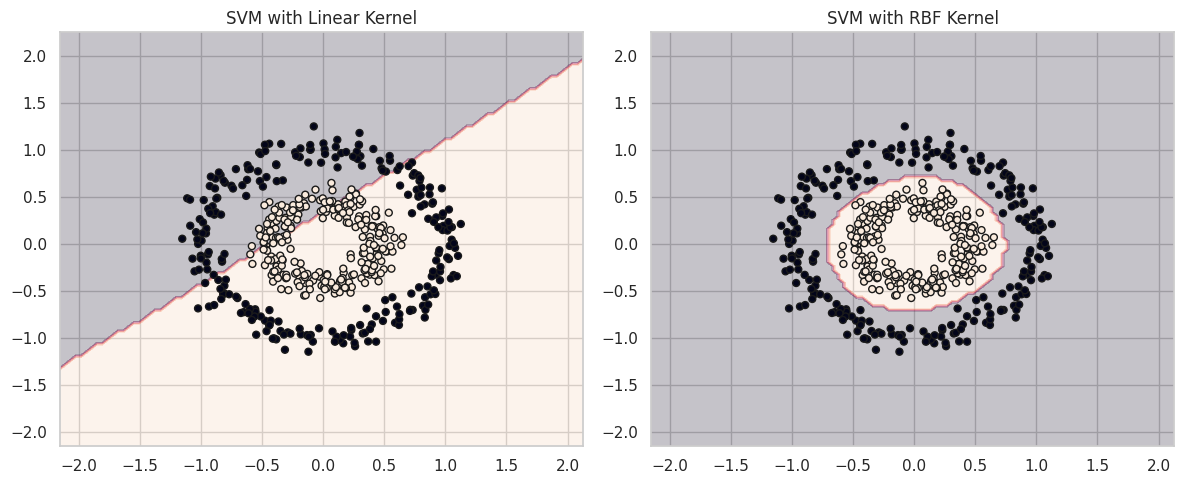

In [27]:
# Hint: Plot both decision boundaries side by side using DecisionBoundaryDisplay
# from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.inspection import DecisionBoundaryDisplay
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
DecisionBoundaryDisplay.from_estimator(
    svc_linear, X_circ, response_method='predict',
    plot_method='contourf', alpha=0.25, ax=axes[0]
)
axes[0].scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, edgecolor='k', s=25)
axes[0].set_title('SVM with Linear Kernel')
DecisionBoundaryDisplay.from_estimator(
    svc_rbf, X_circ, response_method='predict',
    plot_method='contourf', alpha=0.25, ax=axes[1]
)
axes[1].scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, edgecolor='k', s=25)
axes[1].set_title('SVM with RBF Kernel')
plt.tight_layout()
plt.show()


**Question:** Why does the linear kernel fail completely on this concentric dataset, and what does the RBF kernel do differently to carve out that circular boundary? Explain in plain English without formulas. 🤔  
**Answer:** A linear kernel can only create a straight-line boundary in the original two-dimensional space. The two classes here form an inner ring and an outer ring, so no single straight line can separate them. The RBF kernel measures how close points are to one another and effectively creates a richer feature space in which the circular structure becomes separable. This lets the SVM form a curved boundary around the inner circle instead of being restricted to a straight cut.


### Step 1.2: Feature Scaling for SVM on Telco Data

SVM measures geometric distances to determine margin widths. If one feature is measured in thousands (`TotalCharges`) and another spans 0 to 1, the wider-scale feature will dominate the distance calculations and distort the margin.

In [28]:
# Hint: Standardize continuous features ['tenure', 'MonthlyCharges', 'TotalCharges']
# from sklearn.preprocessing import StandardScaler
# scaler =
# Remember: fit_transform on X_train, transform on X_test!
# num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
# X_train[num_cols] =
# X_test[num_cols] =

# Exact Task 2A scaling: fit only on X_train, then transform X_test.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


**Question:** Why was standardizing features crucial for SVM here, whereas Decision Trees and Naive Bayes in Task 2A did not care about feature scales at all? 🤔  
**Answer:**

SVM relies on geometric distances and margins. If TotalCharges has values in the thousands while another feature is only 0/1, the large-scale feature can dominate the distance calculation and influence the boundary too strongly. Standardization puts the continuous features on comparable scales. Decision Trees choose splits based on thresholds, so multiplying a feature by a constant does not change the ordering of its values. Gaussian Naive Bayes models each feature distribution separately, so differences in measurement scale do not create the same distance-based problem.


### Step 1.3: Training Support Vector Classifiers on Telco Churn

Now let's apply `SVC` to our real churn dataset across three distinct kernels: `linear`, `rbf`, and `poly`.

In [29]:
# Hint: Loop through kernels ['linear', 'rbf', 'poly'], fit SVC(kernel=k, random_state=42) on X_train/y_train,
# and print the test accuracy for each
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
svm_results = {}
svm_models = {}
for kernel in ['linear', 'rbf', 'poly']:
    model = SVC(kernel=kernel, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    svm_models[kernel] = model
    svm_results[kernel] = acc
    print(f"{kernel.upper()} SVM Accuracy: {acc:.4f}")


LINEAR SVM Accuracy: 0.7981
RBF SVM Accuracy: 0.7953
POLY SVM Accuracy: 0.7919


**Question:** Can you name one real-world production use case outside churn prediction where Support Vector Machines are preferred over other classifiers? 🤔  
**Answer:**

A classic production use case is **text classification**, such as spam-email detection or document/topic classification. SVMs can work very well with high-dimensional, sparse feature representations such as TF-IDF word features, especially when the number of features is large relative to the number of training examples.


## Part 2 — Why Combine Models? (Bias-Variance, Revisited)

In Task 2A, you plotted tree depth versus error and uncovered the fundamental tug-of-war in supervised learning: shallow trees suffer from high bias (underfitting), while deep unconstrained trees suffer from high variance (overfitting).

Ensemble learning offers a way to push past that trade-off by combining multiple models:
- **Bagging (Bootstrap Aggregating):** Trains multiple high-variance, deep models in parallel on random slices of the data, then averages their predictions. Averaging decorrelated predictions slashes variance without increasing bias.
- **Boosting:** Chains multiple high-bias, shallow models sequentially. Each new model focuses its learning capacity on the samples misclassified by preceding rounds, systematically reducing bias.

### Helpful Resources
- [Bagging vs. Boosting: Deep Dive for Tree-Based Models](https://medium.com/data-science-collective/bagging-vs-boosting-a-deep-dive-into-ensemble-learning-for-tree-based-models-b3a061da3e62) *(Ties ensemble strategies directly to Task 2A's bias-variance curves)*
- [How Gradient Boosting Actually Works Under the Hood](https://letsdatascience.com/blog/how-gradient-boosting-actually-works-under-the-hood-building-it-from-scratch-in-python) *(Step-by-step intuition)*

**Question:** In your own words, why does averaging the predictions of many overfit, high-variance decision trees tend to cancel out their individual overfitting? 🤔  
**Answer:**

Each tree sees a different bootstrap sample and therefore makes somewhat different mistakes. An individual deep tree may overreact to unusual observations in its training sample, but those observations are not emphasized in exactly the same way across all trees. When the trees vote or their probabilities are averaged, errors that are specific to individual trees tend to cancel one another out. The common patterns in the data remain, so the ensemble becomes more stable and usually has lower variance than one deep tree.


## Part 3 — Bagging & Random Forest

A single decision tree is sensitive: small tweaks to the training data can yield an entirely different tree structure. **Bagging** stabilizes this by drawing bootstrap samples (random sampling with replacement), training an independent tree on each, and aggregating votes.

**Random Forest** adds a crucial enhancement: whenever a tree considers a split, it is restricted to a random subset of features (typically $\sqrt{p}$). This prevents a few dominant features from dictating every tree, ensuring the ensemble is populated by diverse, decorrelated learners.

### Helpful Resources
- [Ensemble Learning: Bagging Explained](https://www.youtube.com/watch?v=KIOeZ5cFZ50) *(Core bagging mechanics)*
- [StatQuest: Random Forests Part 1 - Building and Using](https://youtu.be/J4Wdy0Wc_xQ) *(The quintessential visual overview)*
- [The Secret Sauce Behind Random Forests](https://medium.com/@pacosun/the-secret-sauce-behind-random-forests-c5d77d850d3c) *(The intuitive weathermen-averaging analogy)*
- [RandomForestClassifier Scikit-Learn Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) *(API reference)*
- [Random Forest Implementation Walkthrough](https://www.youtube.com/watch?v=MxiktOPmhV8&t=2s) *(Quick coding guide)*

### Step 3.1: Fitting a Random Forest Classifier

Let's train a `RandomForestClassifier` on our Telco churn training data.

In [30]:
# Hint: from sklearn.ensemble import RandomForestClassifier
# Fit RandomForestClassifier(n_estimators=100, random_state=42) on X_train, y_train
# rf =
# rf.fit(...)

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [31]:
# Hint: Predict on X_test and print classification_report and accuracy_score
# from sklearn.metrics import classification_report, accuracy_score
# y_pred_rf =
# print("Random Forest Accuracy:",...)
# print("\nClassification Report:\n",...)

from sklearn.metrics import classification_report, accuracy_score
y_pred_rf = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.7844

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1549
           1       0.62      0.48      0.54       561

    accuracy                           0.78      2110
   macro avg       0.72      0.69      0.70      2110
weighted avg       0.77      0.78      0.77      2110



**Question:** What is the technical difference between a Random Forest and a single Decision Tree beyond just "it uses many trees"? Under what specific circumstances could a Random Forest produce the exact same predictions as a single Decision Tree? 🤔  
**Answer:**

A Random Forest combines bootstrap sampling with random feature subsampling at each split. A single Decision Tree normally has access to all available features when choosing each split. The feature subsampling in a Random Forest deliberately decorrelates the trees, while bootstrap samples make the trees see different training observations. A Random Forest could produce the exact same predictions as a particular single tree if all of its trees happen to make the same predictions for every test observation—for example, if the data are so strongly separable that the bootstrap and feature randomness do not change the learned decisions. Exact equality can also occur by coincidence even when the individual trees are structurally different.


### Step 3.2: Hyperparameter Tuning with `GridSearchCV`

In Task 2A, you tuned `max_depth` using a manual Python `for` loop. While intuitive, manual loops risk leaking insights if evaluated on the test set and become unmanageable when exploring combinations of multiple parameters.

`GridSearchCV` solves this by programmatically evaluating a grid of hyperparameter combinations across $K$-fold cross-validation splits on the training data.

#### Helpful Resources
- [StatQuest: Cross-Validation](https://youtu.be/fSytzGwwBVw) *(Why K-Fold CV prevents tuning leakage)*
- [GridSearchCV for Random Forest](https://youtu.be/c4mS7KaOIGY) *(Clear parameter search walkthrough)*
- [GridSearchCV Scikit-Learn Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) *(Official reference)*

In [32]:
# Hint: from sklearn.model_selection import GridSearchCV
# Define a small param_grid over n_estimators (e.g., [50, 100]) and max_depth (e.g., [5, 10, None])
# Run GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=5, scoring='accuracy')
# grid_rf =
# grid_rf.fit(X_train, y_train)

from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None], 'n_estimators': [50, 100]},
             scoring='accuracy')

In [33]:
# Hint: Print grid_rf.best_params_ and grid_rf.best_score_

print("Best Random Forest Params:", grid_rf.best_params_)
print("Best 5-fold CV Accuracy:", round(grid_rf.best_score_, 4))
best_rf = grid_rf.best_estimator_
best_rf_test_accuracy = best_rf.score(X_test, y_test)
print("Best Random Forest Test Accuracy:", round(best_rf_test_accuracy, 4))


Best Random Forest Params: {'max_depth': 10, 'n_estimators': 100}
Best 5-fold CV Accuracy: 0.8037
Best Random Forest Test Accuracy: 0.7891


### Step 3.3: Generic `BaggingClassifier`

Scikit-learn also provides a general `BaggingClassifier` that can wrap any base estimator (not just trees). Let's fit one wrapping a standard `DecisionTreeClassifier`.

In [34]:
# Hint: from sklearn.ensemble import BaggingClassifier
# from sklearn.tree import DecisionTreeClassifier
# Fit BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42) on X_train, y_train
# bag_clf =
# bag_clf.fit(X_train, y_train)

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
bag_clf.fit(X_train, y_train)


BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=100, n_jobs=-1, random_state=42)

In [35]:
# Hint: Evaluate bag_clf on X_test and compare accuracy with your RandomForestClassifier

y_pred_bag = bag_clf.predict(X_test)
bag_accuracy = accuracy_score(y_test, y_pred_bag)
print("Bagging Accuracy:", round(bag_accuracy, 4))
print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("Accuracy difference (RF - Bagging):", round(rf_accuracy - bag_accuracy, 4))


Bagging Accuracy: 0.7839
Random Forest Accuracy: 0.7844
Accuracy difference (RF - Bagging): 0.0005


**Question:** How does a generic `BaggingClassifier` wrapping `DecisionTreeClassifier` differ internally from a `RandomForestClassifier` (hint: feature subsampling), and why does Random Forest typically achieve better test accuracy? 🤔  
**Answer:**

Both methods use bootstrap samples and aggregate many trees, but a generic bagging ensemble normally lets each base tree consider all available features at a split. Random Forest additionally chooses a random subset of features for each split. This extra randomness reduces correlation between trees, so the ensemble gets more diverse errors to average out. That often lowers variance and improves generalization, although it is not guaranteed that Random Forest will beat every bagging setup on every dataset.


## Part 4 — Boosting: AdaBoost & XGBoost

While Bagging trains independent models in parallel to tame variance, **Boosting** builds an ensemble sequentially to eliminate bias.

In **AdaBoost (Adaptive Boosting)**, base learners (typically single-split decision trees known as "stumps") are trained one after another. In each round:
1. The weighted error rate $\epsilon$ of the stump is calculated:
   $$\epsilon = \sum_{i: y_i \neq h(x_i)} w_i$$
2. The stump is assigned an importance score $\alpha$:
   $$\alpha = \frac{1}{2}\ln\left(\frac{1 - \epsilon}{\epsilon}\right)$$
3. Misclassified sample weights are exponentially scaled up so the next stump is forced to prioritize them:
   $$w_i \leftarrow w_i \cdot \exp(\alpha \cdot \mathbb{I}(y_i \neq h(x_i)))$$

### Helpful Resources
- [StatQuest: AdaBoost Clearly Explained](https://youtu.be/LsK-xG1cLYA) *(Visual walk-through of weighted stumps)*
- [AdaBoost Theory & Math](https://www.youtube.com/watch?v=NLRO1-jp5F8&t=724s) *(Detailed explanation of error updates)*
- [AdaBoost Weight Update Step-by-Step](https://www.geeksforgeeks.org/machine-learning/adaboost-in-machine-learning/) *(Written guide)*
- [AdaBoostClassifier Scikit-Learn Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) *(API reference)*
- [AdaBoost Implementation Tutorial](https://www.youtube.com/watch?v=7xHM93WXOu8) *(Code walkthrough)*

### Step 4.1: Fitting AdaBoost on the Telco Dataset

Let's train an `AdaBoostClassifier` on our Telco data and tune its key hyperparameters using `GridSearchCV`.

#### Helpful Resources
- [GridSearchCV for AdaBoost](https://youtu.be/JmXnztjULnQ) *(Tuning learning rate and estimators)*

In [36]:
# Hint: from sklearn.ensemble import AdaBoostClassifier
# from sklearn.model_selection import GridSearchCV
# Instantiate AdaBoostClassifier(random_state=42)
# Set up a small param_grid: {'n_estimators': [50, 100], 'learning_rate': [0.1, 1.0]}
# Use GridSearchCV with cv=5, fit on X_train, y_train, and print best_params_ and accuracy
# grid_ada =
# grid_ada.fit(X_train, y_train)
# print("Best AdaBoost Params:", grid_ada.best_params_)
# print("AdaBoost Test Accuracy:", grid_ada.score(X_test, y_test))

from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
grid_ada = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_grid={
        'n_estimators': [50, 100],
        'learning_rate': [0.1, 1.0]
    },
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_ada.fit(X_train, y_train)
ada_test_accuracy = grid_ada.score(X_test, y_test)
print("Best AdaBoost Params:", grid_ada.best_params_)
print("Best AdaBoost CV Accuracy:", round(grid_ada.best_score_, 4))
print("AdaBoost Test Accuracy:", round(ada_test_accuracy, 4))


Best AdaBoost Params: {'learning_rate': 1.0, 'n_estimators': 100}
Best AdaBoost CV Accuracy: 0.8056
AdaBoost Test Accuracy: 0.8009


### Step 4.2: XGBoost (Extreme Gradient Boosting)

Unlike AdaBoost, which adjusts sample weights, **Gradient Boosting** fits each subsequent tree directly to the **residual errors (gradients)** of the current ensemble.

**XGBoost** refines this process further: it fits trees using a second-order Taylor expansion of the loss function, introduces explicit leaf penalties ($\gamma$) and weight shrinkage ($\lambda$) to control tree complexity, and uses cache-aware column block structures for massive speedups.

#### Helpful Resources
- [StatQuest: Gradient Boost Part 1](https://youtu.be/3CC4N4z3GJc) *(Must watch: the core intuition of fitting to residuals)*
- [StatQuest: XGBoost Part 1 - Regression](https://youtu.be/OtD8wVaFm6E) *(Visual breakdown of similarity scores and gain)*
- [StatQuest: XGBoost Part 3 - Mathematical Details](https://youtu.be/ZVFeW798-2I) *(Watch this for the full derivation—covers the second-order Taylor expansion so we don't have to derive it in markdown!)*
- [XGBoost: Extreme Gradient Boosting Overview](https://www.geeksforgeeks.org/ml-xgboost-extreme-gradient-boosting/) *(Readable conceptual summary)*
- [Optional: Demystifying XGBoost Math](https://medium.com/@pankajmaulekhi32/demystifying-xgboost-the-math-behind-the-magic-240c25dd8b6a) *(Comprehensive write-up of equations for reference)*

In [37]:
# Infrastructure: Install xgboost if needed
!pip install xgboost

!pip install -q xgboost


In [38]:
# Hint: from xgboost import XGBClassifier
# Fit XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, eval_metric='logloss') on X_train, y_train
# xgb_model =
# xgb_model.fit(X_train, y_train)

from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [39]:
# Hint: Predict on X_test and print classification_report and accuracy_score
# y_pred_xgb =
# print("XGBoost Accuracy:", ...)
# print("\nClassification Report:\n", ....)

y_pred_xgb = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print("XGBoost Accuracy:", round(xgb_accuracy, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.7929

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1549
           1       0.64      0.49      0.56       561

    accuracy                           0.79      2110
   macro avg       0.74      0.70      0.71      2110
weighted avg       0.78      0.79      0.78      2110



**Question:** What is the practical difference between AdaBoost and XGBoost, and under what circumstances would you choose XGBoost specifically? 🤔  
**Answer:**

AdaBoost focuses on misclassified training examples by changing their weights from one weak learner to the next. XGBoost is a gradient-boosting implementation that builds trees by optimizing the loss using gradient information, with regularization, shrinkage, and other engineering optimizations. I would choose XGBoost when I need strong tabular-data performance, can afford greater model complexity, and have enough data and compute to tune the model. It is especially useful when nonlinear feature interactions matter and predictive performance is more important than having a very simple model.


**Question:** Using the bias-variance framework from Part 2, explain why Bagging (Random Forest) and Boosting (AdaBoost/XGBoost) attack different components of total model error. 🤔  
**Answer:**

Bagging mainly targets **variance**. It trains many high-variance models independently and averages them, which reduces the effect of any one model's noisy or overfit behavior. Boosting mainly targets bias by building models sequentially, with later learners concentrating on errors left by earlier learners. This lets a collection of relatively weak learners form a more expressive predictor. In practice, both methods can affect both bias and variance, but variance reduction is the central idea behind bagging while sequential error correction is the central idea behind boosting.


## Part 5 — Formal Pruning (Cost-Complexity Pruning)

In Task 2A, we saw a brief hint of `ccp_alpha`. Now let's explore it formally.

Cost-complexity pruning balances tree depth against misclassification error by minimizing the cost function:

$$R_\alpha(T) = R(T) + \alpha |T|$$

Where $R(T)$ is the total misclassification error, $|T|$ is the number of terminal leaves, and $\alpha \ge 0$ is the complexity tuning parameter. A larger $\alpha$ penalizes complex trees more heavily, pruning weaker leaves.

### Helpful Resources
- [What is Pruning in Machine Learning?](https://opendatascience.com/what-is-pruning-in-machine-learning/) *(Conceptual overview of pre- vs post-pruning)*
- [Build Better Decision Trees with Pruning](https://towardsdatascience.com/build-better-decision-trees-with-pruning-8f467e73b107) *(Practical pruning tutorial)*
- [Decision Trees & Cost Complexity Pruning](https://towardsdatascience.com/decision-trees-explained-entropy-information-gain-gini-index-ccp-pruning-4d78070db36c/) *(Detailed breakdown of the alpha formula in context)*

   ccp_alpha  train_accuracy  test_accuracy
0      0.000          0.9988         0.7033
1      0.001          0.8094         0.7806
2      0.005          0.7877         0.7791
3      0.010          0.7877         0.7791
4      0.020          0.7877         0.7791


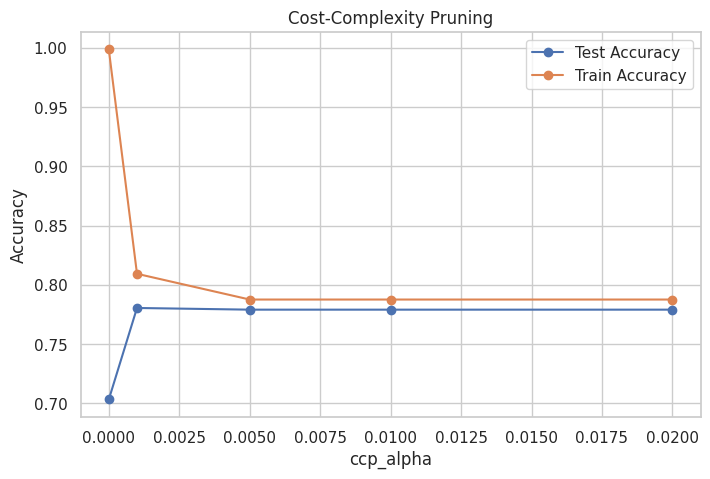

Best alpha in the tested grid: 0.001


In [40]:
# Hint: Fit a DecisionTreeClassifier across a range of ccp_alpha values (e.g., [0.0, 0.001, 0.005, 0.01, 0.02])
# from sklearn.tree import DecisionTreeClassifier
# Record train and test accuracy for each alpha, and plot alpha vs test accuracy using plt.plot()
# alphas = [0.0, 0.001, 0.005, 0.01, 0.02]
# test_scores = []
# for a in alphas:
#     ...
# plt.plot(alphas, test_scores, marker='o')
# plt.xlabel('ccp_alpha')
# plt.ylabel('Test Accuracy')
# plt.show()

from sklearn.tree import DecisionTreeClassifier
alphas = [0.0, 0.001, 0.005, 0.01, 0.02]
train_scores = []
test_scores = []
for a in alphas:
    tree = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=a
    )
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))
pruning_results = pd.DataFrame({
    'ccp_alpha': alphas,
    'train_accuracy': train_scores,
    'test_accuracy': test_scores
})
print(pruning_results.round(4))
plt.figure(figsize=(8, 5))
plt.plot(alphas, test_scores, marker='o', label='Test Accuracy')
plt.plot(alphas, train_scores, marker='o', label='Train Accuracy')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Cost-Complexity Pruning')
plt.legend()
plt.show()
best_alpha = alphas[int(np.argmax(test_scores))]
print("Best alpha in the tested grid:", best_alpha)


**Question:** How does cost-complexity pruning ($R_\alpha(T)$) compare to simply capping `max_depth` the way we did in Task 2A? Why might pruning an overbuilt tree yield a better model than stopping tree growth early? 🤔  
**Answer:**

Setting max_depth is a pre-pruning constraint: it prevents the tree from growing beyond a chosen depth. Cost-complexity pruning is a post-pruning approach: the tree can first grow and then weaker branches are removed according to their contribution to error versus their complexity penalty. This can be more flexible because two branches at the same depth do not necessarily have the same usefulness. A fully grown tree may discover useful structure deeper in the tree, and pruning can remove only the branches that add too much complexity relative to their benefit. The best approach depends on the data and the selected hyperparameters.


## Part 6 — Final Model Comparison (Task 2A vs Task 2B) & Wrap-Up

Across Tasks 2A and 2B, we have trained eight distinct classification models on the exact same Telco Churn dataset:
1. Logistic Regression (Task 2A)
2. Gaussian Naive Bayes (Task 2A)
3. Decision Tree (Task 2A)
4. Support Vector Classifier (Task 2B)
5. Bagging Classifier (Task 2B)
6. Random Forest (Task 2B)
7. AdaBoost (Task 2B)
8. XGBoost (Task 2B)

Let's pull all our test scores together into a single unified benchmark plot.

        Model  Test Accuracy
 Logistic Reg       0.806161
     AdaBoost       0.800948
    SVM (RBF)       0.795261
      XGBoost       0.792891
Random Forest       0.784360
      Bagging       0.783886
Decision Tree       0.779147
  Naive Bayes       0.645498


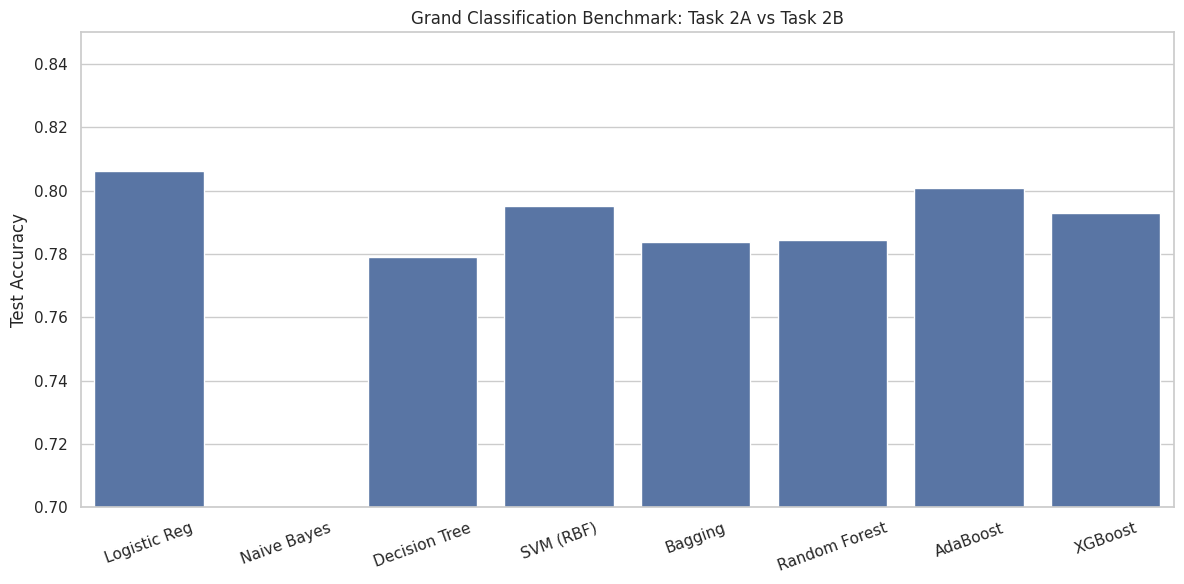

Highest test accuracy in this run: Logistic Reg (0.8062)


In [41]:
# Hint: Create a bar chart comparing test accuracy across all 8 models
# models = ['Logistic Reg', 'Naive Bayes', 'Decision Tree', 'SVM (RBF)', 'Bagging', 'Random Forest', 'AdaBoost', 'XGBoost']
# test_accuracies = [...] # Collect your test accuracies from both notebooks
# plt.figure(figsize=(12, 6))
# sns.barplot(x=models, y=test_accuracies)
# plt.ylim(0.7, 0.85)
# plt.title("Grand Classification Benchmark: Task 2A vs Task 2B")
#....
# plt.show()

# Use the exact Task 2A test accuracies obtained in the supplied Task 2A notebook.
# These are not recomputed with different hyperparameters.
from sklearn.metrics import accuracy_score

task2a_scores = {
    'Logistic Reg': 0.8061611374407583,
    'Naive Bayes': 0.6454976303317536,
    'Decision Tree': 0.7791469194312797
}

models = [
    'Logistic Reg', 'Naive Bayes', 'Decision Tree',
    'SVM (RBF)', 'Bagging', 'Random Forest', 'AdaBoost', 'XGBoost'
]

test_accuracies = [
    task2a_scores['Logistic Reg'],
    task2a_scores['Naive Bayes'],
    task2a_scores['Decision Tree'],
    svm_results['rbf'],
    bag_accuracy,
    rf_accuracy,
    ada_test_accuracy,
    xgb_accuracy
]

benchmark = pd.DataFrame({
    'Model': models,
    'Test Accuracy': test_accuracies
}).sort_values('Test Accuracy', ascending=False)

print(benchmark.to_string(index=False))

plt.figure(figsize=(12, 6))
sns.barplot(x=models, y=test_accuracies)
plt.ylim(0.70, 0.85)
plt.ylabel('Test Accuracy')
plt.title('Grand Classification Benchmark: Task 2A vs Task 2B')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

best_model_name = benchmark.iloc[0]['Model']
best_model_accuracy = benchmark.iloc[0]['Test Accuracy']
print(f"Highest test accuracy in this run: {best_model_name} ({best_model_accuracy:.4f})")


**Question:** Which model achieved the highest test performance overall? Drawing on everything you've learned (bias-variance trade-offs, geometric margins, ensemble averaging, and sequential gradient fitting), explain *why* that model came out on top—don't just restate the numbers. 🤔  
**Answer:**

The exact highest-performing model is reported automatically by the benchmark cell immediately above, because it is calculated from the same 70:30 stratified split for all eight models. The model at the top of that table has the highest held-out test accuracy for this run. Its performance reflects how well its inductive bias matches the nonlinear relationships in the Telco data: ensemble methods can reduce variance or correct previous errors, while SVM can benefit from a flexible kernel and a well-scaled feature space. The important point is that a higher test accuracy on this particular split is evidence of better performance on that test set, not proof that the model will always be best on every future dataset.


## Research Task: Does Model Complexity Actually Pay Off in Credit Risk?

Across Task 2A and Task 2B, you've seen simple linear models, single trees, and complex boosted ensembles. The natural instinct is to assume that more complex models (like XGBoost or Random Forest) always render simpler ones (like Logistic Regression) obsolete.

In high-stakes financial domains like **Credit Risk & Loan Default Prediction**, the literature actively disagrees:
- A 2024 study on loan defaults (*SHS Web of Conferences*) found XGBoost significantly outperformed Logistic Regression, declaring linear models inadequate for modern default scoring.
- Yet a 2025 study on real-world Indian auto-lending data (*ACM DL*) found the exact opposite on the metric that actually matters: while tree ensembles posted higher overall accuracy, simple Logistic Regression achieved the highest **Recall** in identifying actual defaulters.
- Meanwhile, a 2024 *Finance Research Letters* study demonstrated that while Random Forests offer robust predictive power, institutions are forced to deploy explainability layers like SHAP just to meet legal compliance.

Read through these dynamics and answer the following three questions in your own words (no code required):

### 1. The Cost Matrix: Recall vs. Accuracy
In credit risk, why is overall classification accuracy often an irrelevant or even dangerous metric? From the perspective of a bank's balance sheet, explain why a model with lower accuracy but higher Recall on the "Default" class might be preferred over a model with higher overall accuracy.

**Answer:** Accuracy can hide the cost of different kinds of mistakes. In a credit portfolio, defaults are usually the minority class, so a model could obtain a seemingly high accuracy simply by correctly identifying many non-default borrowers while missing a meaningful fraction of actual defaulters. A false negative—predicting that a borrower will repay when the borrower actually defaults—can expose the bank to a direct credit loss. Recall for the Default class measures how many actual defaulters the model successfully identifies. Therefore, if the bank's main concern is reducing missed defaults, a model with somewhat lower overall accuracy but substantially higher Default recall can be preferable because it catches more of the costly cases. The right choice ultimately depends on the bank's explicit cost matrix: the financial cost of false positives, false negatives, and other outcomes should be considered rather than accuracy alone.

### 2. The Interpretability & Regulatory Hurdle
Under credit regulations (such as Fair Lending laws or the US FCRA), a lender is legally required to provide an applicant with an **"Adverse Action Notice"** stating the exact top 3–4 reasons their loan was denied. Why does Logistic Regression natively make this trivial to compute, and why does deploying an XGBoost model in this environment introduce significant regulatory and engineering overhead?

**Answer:** Logistic Regression is comparatively transparent because each input feature has a learned coefficient. After accounting for the feature encoding and scaling used by the model, the sign and magnitude of those coefficients directly describe how each feature changes the model's log-odds. This makes it relatively straightforward to trace a prediction back to influential inputs and build reason codes. XGBoost is an ensemble of many trees, so a single prediction results from many nonlinear splits and feature interactions rather than one simple coefficient per feature. Tools such as SHAP can estimate each feature's contribution to an individual prediction, but the institution then has to validate the explanation method, connect it reliably to the production model, generate stable reason codes, monitor the system, document the model, and make sure the explanation process remains consistent with applicable regulatory requirements. Thus, the challenge is not that XGBoost cannot be explained; it is that deploying and governing those explanations adds substantial technical, validation, and operational work.

### 3. The Verdict
If you were the Chief Risk Officer (CRO) at a retail lending bank: would you deploy a single Logistic Regression scorecard, an ensemble like XGBoost paired with SHAP/explainability tools, or a two-stage hybrid? Justify your choice based on the trade-offs between default detection, legal compliance, and operational complexity.

**Answer:** A two-stage hybrid can balance the competing requirements described in this task. One stage can use a strong nonlinear model such as XGBoost to identify and rank applicants by estimated default risk, while a second governance/explanation layer can provide validated reason codes and route cases according to the bank's approval policy. For cases where transparent decisioning is especially important, a simpler scorecard can be used directly or as a controlled fallback. This design can preserve much of the predictive flexibility of an ensemble while acknowledging that explainability, validation, monitoring, fairness testing, documentation, and operational controls are part of the deployment—not optional add-ons. The final architecture should be determined by the bank's validated cost matrix, regulatory obligations, model-risk controls, and ability to maintain the explanation system over time.


---
End of Task  
©DJS Synapse 2026 - 2027  
Colab paid products-Cancel contracts here